# Simulation results overview

This notebook summarises the deterministic sweep produced by `run_sim.go`. It compares the Kubernetes default scheduler, CarbonScaler, and the heterogeneity-aware policy using the exported CSV artefacts.


In [1]:
from pathlib import Pathimport pandas as pdimport numpy as npimport matplotlib.pyplot as pltrepo_root = Path.cwd().resolve().parents[2]module_root = repo_root / 'kubenergysched'results_dir = module_root / 'results'summary = pd.read_csv(results_dir / 'summary.csv')per_job_frames = []workloads = pd.read_csv(module_root / 'config' / 'workloads.csv')workload_pref = dict(zip(workloads['id'], workloads['preferred_site']))for path in sorted(results_dir.glob('*_results.csv')):    if path.name == 'summary.csv':        continue    df = pd.read_csv(path, parse_dates=['submit','start','end'])    df['policy'] = df['sched']    df['preferred_site'] = df['job_id'].map(workload_pref)    df['mismatch'] = (df['site'] != df['preferred_site']).astype(int)    df['wait_s'] = df['wait_ms'] / 1000.0    df['runtime_s'] = (df['end'] - df['start']).dt.total_seconds()    per_job_frames.append(df)per_job = pd.concat(per_job_frames, ignore_index=True)repo_root, module_root, results_dir

(PosixPath('/workspace/KubEnergySched'), PosixPath('/workspace/KubEnergySched/kubenergysched'), PosixPath('/workspace/KubEnergySched/kubenergysched/results'))

In [2]:
summary


       policy  ci_weight  batch_size  total_ci_cost_g  avg_ci_per_job_g  cfp_g_per_cpu_hour  avg_wait_s  makespan_s  elapsed_ms  num_jobs  alpha_mass  lookahead_min  duration_scale  duration_overrides
   kubernetes        0.4          64         3.350728          0.069807            0.011462     4320.00     15600.0         2.0        48         1.0              0             1.0                 NaN
 carbonscaler        0.4          64         3.058314          0.063715            0.010693     2413.75     15000.0         1.0        48         1.0              0             1.0                 NaN
heterogeneous        0.4          64         3.046470          0.063468            0.010677     2363.75     14700.0         1.0        48         1.0              0             1.0                 NaN

In [3]:
policy_metrics = per_job.groupby('policy').agg(    jobs=('job_id','count'),    avg_wait_s=('wait_s','mean'),    avg_runtime_s=('runtime_s','mean'),    mismatches=('mismatch','sum')).reset_index()policy_metrics = policy_metrics.merge(    summary[['policy','total_ci_cost_g','makespan_s','elapsed_ms']],    on='policy', how='left')policy_metrics[['policy','jobs','total_ci_cost_g','avg_wait_s','makespan_s','avg_runtime_s','mismatches','elapsed_ms']]

       policy  jobs  total_ci_cost_g  avg_wait_s  makespan_s  avg_runtime_s  mismatches  elapsed_ms
 carbonscaler    48         3.058314     2413.75     15000.0         1525.0          14         1.0
heterogeneous    48         3.046470     2363.75     14700.0         1525.0          14         1.0
   kubernetes    48         3.350728     4320.00     15600.0         1575.0          18         2.0

In [4]:
per_job.groupby(['policy','site']).size().unstack(fill_value=0)


site           site-a  site-b
policy                       
carbonscaler       28      20
heterogeneous      28      20
kubernetes         30      18

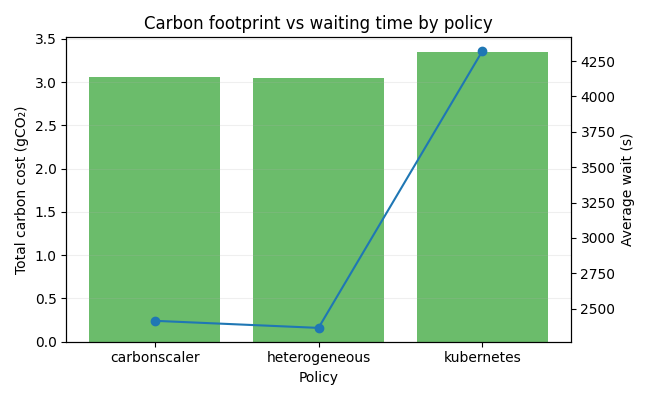

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 4.0))ax.bar(policy_metrics['policy'], policy_metrics['total_ci_cost_g'], color='tab:green', alpha=0.7, label='Total CI (gCO₂)')ax.set_ylabel('Total carbon cost (gCO₂)')ax2 = ax.twinx()ax2.plot(policy_metrics['policy'], policy_metrics['avg_wait_s'], marker='o', color='tab:blue', label='Average wait (s)')ax2.set_ylabel('Average wait (s)')ax.set_xlabel('Policy')ax.set_title('Carbon footprint vs waiting time by policy')ax.grid(axis='y', alpha=0.2)ax.legend(loc='upper left')ax2.legend(loc='upper right')fig.tight_layout()fig

In [6]:
summary[['policy','elapsed_ms']]


       policy  elapsed_ms
   kubernetes         2.0
 carbonscaler         1.0
heterogeneous         1.0